# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.



# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
**Task 1 completed Here :** the tiny 6-line boilerplate corpus has been replaced with a longer,
custom paragraph so the models have more grammar and context to learn from.


In [9]:
corpus = """
deep learning is transforming artificial intelligence across every industry today
recurrent neural networks are useful for sequential data such as text speech and time series
lstm helps remember long term dependencies by using input forget and output gates
gru is faster and simpler than lstm because it uses only reset and update gates
text generation models predict the next word by learning patterns from large amounts of text
deep learning models can generate meaningful sentences once they understand grammar and context
neural networks learn representations of words as dense vectors called embeddings
training a language model requires feeding it many examples of real sentences
the more data a model sees the better it becomes at predicting the next word
attention mechanisms and transformers have further improved sequence modeling beyond rnns and lstms
students learning deep learning should experiment with different architectures to understand tradeoffs
comparing simple rnn lstm and gru helps build intuition about memory and gradient flow
"""
print(corpus)


deep learning is transforming artificial intelligence across every industry today
recurrent neural networks are useful for sequential data such as text speech and time series
lstm helps remember long term dependencies by using input forget and output gates
gru is faster and simpler than lstm because it uses only reset and update gates
text generation models predict the next word by learning patterns from large amounts of text
deep learning models can generate meaningful sentences once they understand grammar and context
neural networks learn representations of words as dense vectors called embeddings
training a language model requires feeding it many examples of real sentences
the more data a model sees the better it becomes at predicting the next word
attention mechanisms and transformers have further improved sequence modeling beyond rnns and lstms
students learning deep learning should experiment with different architectures to understand tradeoffs
comparing simple rnn lstm and gru

# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [10]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 118
X shape: (146, 14)
y shape: (146,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

**Tasks 2 & 4 completed Here :** embedding dimension raised from 32 → 64 and hidden units
raised from 64 → 128 for all three models below.

In [11]:
EMBED_DIM = 64
HIDDEN_UNITS = 128
EPOCHS = 200

rnn_model = Sequential([
    Embedding(total_words, EMBED_DIM, input_length=max_len-1),
    SimpleRNN(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("Vanilla RNN training completed")
print("Final loss:", rnn_history.history['loss'][-1])

Vanilla RNN training completed
Final loss: 0.02061273530125618


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [12]:
lstm_model = Sequential([
    Embedding(total_words, EMBED_DIM, input_length=max_len-1),
    LSTM(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("LSTM training completed")
print("Final loss:", lstm_history.history['loss'][-1])

LSTM training completed
Final loss: 0.08905049413442612


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [13]:
gru_model = Sequential([
    Embedding(total_words, EMBED_DIM, input_length=max_len-1),
    GRU(HIDDEN_UNITS),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)
print("GRU training completed")
print("Final loss:", gru_history.history['loss'][-1])

GRU training completed
Final loss: 0.022728482261300087


## 📉 Compare Training Loss : This plot lets you visually check how quickly each architecture converges over all 200 epochs.

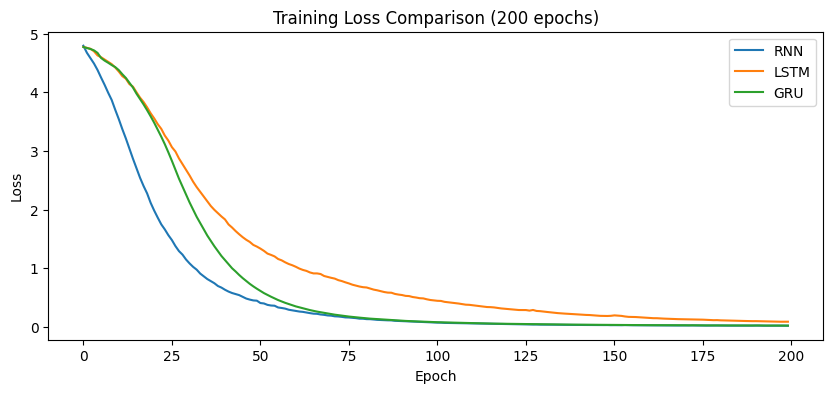

In [14]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (200 epochs)")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

**Task 5 completed Here :** default next_words is now 10 instead of 5.

In [15]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples Each model now generates **10 words** from the same seed phrase.

In [16]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning is transforming artificial intelligence across every industry today text speech
LSTM: deep learning is transforming artificial intelligence across every industry today today tradeoffs
GRU : deep learning is transforming artificial intelligence across every industry today today today


# 📚 Student Learning Tasks
### ✅ Beginner Tasks — all completed in this notebook
1. ✅ Replaced corpus with a custom, longer paragraph
2. ✅ Increased embedding dimension (32 → 64)
3. ✅ Increased epochs to 200
4. ✅ Changed hidden units 64 → 128
5. ✅ Generate 10 words instead of 5



# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

